### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

[8.85573773e-02 7.36546173e+00 6.35159941e-01 3.23767751e-01
 1.93141797e+00 9.94589429e-01 4.47471921e-01 7.55665215e-01
 8.25647943e-01 1.70965313e+00 1.15347329e-01 2.05375293e+00
 1.50924672e+00 3.05256258e+00 7.94162233e-01 1.05478509e+00
 7.11247871e-01 3.06181739e+00 2.37847109e+00 5.25980448e-01
 4.40418345e-01 3.02018523e+00 6.99483929e-01 8.09815898e-02
 7.81820880e-01 4.29776647e-01 1.00739531e+00 1.50571222e+00
 1.08893116e+00 1.74566483e-01 7.32379394e-01 2.06905778e+00
 3.05029580e-01 2.17447486e+00 6.22642857e-01 1.16437999e+00
 5.42671188e-01 3.67550091e+00 3.07461359e+00 7.45927459e-01
 5.33119923e-01 1.45558763e-01 1.12317401e+00 3.91655170e+00
 4.45213733e+00 1.19112973e+00 2.17973275e-01 3.37377229e+00
 3.98850113e-01 1.38979282e+00 4.34460726e-01 2.84224006e-01
 9.71061223e-01 1.84957349e-03 2.52542792e-02 1.37080773e-01
 4.84388547e-01 3.79183974e-01 2.48977583e+00 3.39197912e-01
 3.10192235e-01 1.91247204e-01 4.46787041e-01 3.37399299e-01
 1.55842473e+00 1.992927

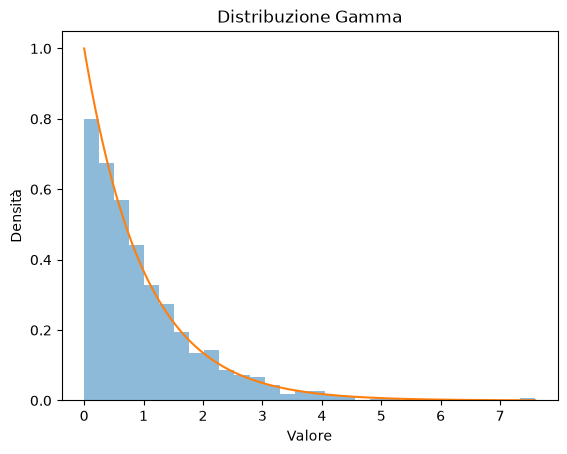

(np.float64(1.0475166750227292), np.float64(0.0005476865366870155), np.float64(0.9650277669947948))
Parametro di forma stimato: 1.0475166750227292


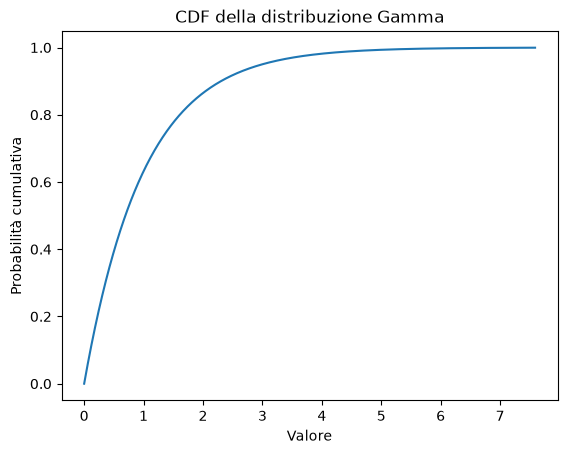

Varianza: 1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# Distribuzione gamma
gamma = sp.stats.gamma(1)

campione = gamma.rvs(size=1000)

print(campione)

# Istogramma con pdf
x = np.linspace(0, campione.max(), 1000)

plt.hist(
    campione,
    bins=30,
    density=True,
    alpha=0.5
)

plt.plot(
    x,
    gamma.pdf(x)
)

plt.xlabel("Valore")
plt.ylabel("Densità")
plt.title("Distribuzione Gamma")

plt.show()

# Uso il campione per stimare
parametri = sp.stats.gamma.fit(campione)

print(parametri)

forma_stimata = parametri[0]

print("Parametro di forma stimato:", forma_stimata)

# Extra
plt.plot(
    x,
    gamma.cdf(x)
)

plt.xlabel("Valore")
plt.ylabel("Probabilità cumulativa")
plt.title("CDF della distribuzione Gamma")

plt.show()

varianza = gamma.var()

print("Varianza:", varianza)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

MAE max: 1.0458509745808575
RMSE max: 1.1946466156624638
MAE min: 3.185078652291967
RMSE min: 3.831099569192345


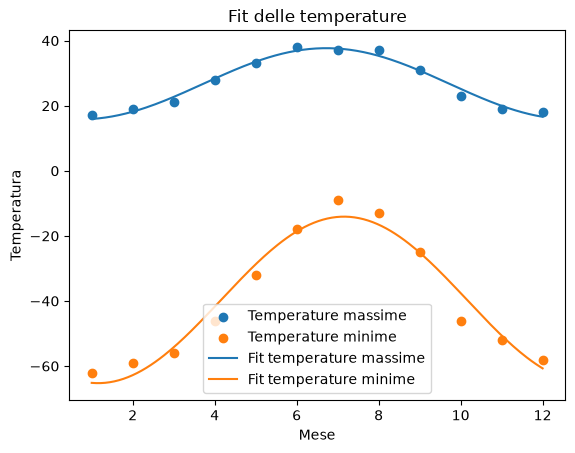

In [2]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Usiamo la sinusoide
mesi = np.arange(1, 13)

def sinusoide(x, a, b, c):
    return a * np.sin(2 * np.pi * x / 12 + b) + c

# Fittiamo le temperature massime
param_max, _ = curve_fit(
    sinusoide,
    mesi,
    temp_max,
    p0=[10, -2, np.mean(temp_max)]
)

pred_max = sinusoide(mesi, *param_max)

# Ora le minime
param_min, _ = curve_fit(
    sinusoide,
    mesi,
    temp_min,
    p0=[25, -2, np.mean(temp_min)]
)

pred_min = sinusoide(mesi, *param_min)

# MAE e RMSE per le massime
mae_max = np.mean(np.abs(temp_max - pred_max))
rmse_max = np.sqrt(np.mean((temp_max - pred_max) ** 2))

print("MAE max:", mae_max)
print("RMSE max:", rmse_max)

# Ora le minime
mae_min = np.mean(np.abs(temp_min - pred_min))
rmse_min = np.sqrt(np.mean((temp_min - pred_min) ** 2))

print("MAE min:", mae_min)
print("RMSE min:", rmse_min)

# Visualizziamo
x_fit = np.linspace(1, 12, 200)

plt.scatter(mesi, temp_max, label="Temperature massime")
plt.scatter(mesi, temp_min, label="Temperature minime")

plt.plot(
    x_fit,
    sinusoide(x_fit, *param_max),
    label="Fit temperature massime"
)

plt.plot(
    x_fit,
    sinusoide(x_fit, *param_min),
    label="Fit temperature minime"
)

plt.xlabel("Mese")
plt.ylabel("Temperatura")
plt.title("Fit delle temperature")

plt.legend()
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

LinregressResult(slope=np.float64(-0.04121511996278614), intercept=np.float64(29.59985475616395), rvalue=np.float64(-0.8475513792624786), pvalue=np.float64(9.380326537381486e-10), stderr=np.float64(0.004711833309637005), intercept_stderr=np.float64(1.2297195153123266))
Pendenza: -0.04121511996278614
Intercetta: 29.59985475616395
Correlazione: -0.8475513792624786
P-value: 9.380326537381486e-10


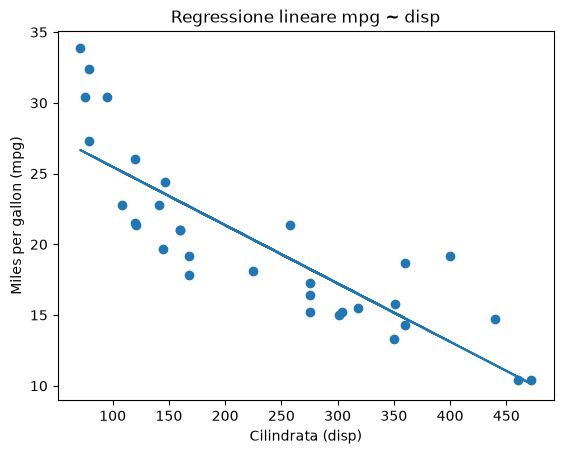

In [3]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

x = df["disp"]
y = df["mpg"]

# Regressione
reg = sp.stats.linregress(x, y)

print(reg)

# Visualzizziamo i valori principali
print("Pendenza:", reg.slope)
print("Intercetta:", reg.intercept)
print("Correlazione:", reg.rvalue)
print("P-value:", reg.pvalue)

# Creiamo la retta 
y_pred = reg.slope * x + reg.intercept

# Grafico
plt.scatter(x, y)

plt.plot(x, y_pred)

plt.xlabel("Cilindrata (disp)")
plt.ylabel("Miles per gallon (mpg)")
plt.title("Regressione lineare mpg ~ disp")

plt.show()